(unit_level_counterfactuals)=
# Unit-level counterfactuals: abduction, action, and prediction

:::{post} March, 2026
:tags: causal inference, counterfactuals, structural causal models, Pearl
:category: intermediate, explanation
:author: Benjamin T. Vincent
:::

Joe participated in an after-school encouragement program. He spent moderate time in the program ($X = 0.5$), did 1 hour of homework ($H = 1.0$), and scored 1.5 on his exam ($Y = 1.5$). His teacher asks: **"What would Joe's exam score have been if he had doubled his homework to $H = 2$?"**

This is not a question about what happens on average when we assign everyone to do 2 hours of homework. It is about one specific student whose abilities, motivation, and circumstances have already been observed.

The standard causal tool for "what if?" questions is the do-operator: $E[Y \mid \operatorname{do}(H\!=\!2)]$. But the do-operator answers a population-level question — rung 2 of Pearl's causal ladder — not an individual one. For Joe, it predicts a score of approximately $0.8$, which is *below* his actual score of $1.5$. The population intervention treats Joe as if he were average, discarding the individual characteristics that made him score above average.

A **unit-level counterfactual** (rung 3) conditions on Joe's observed data before intervening. It infers that Joe has above-average inherent ability, and predicts a counterfactual score of approximately $1.9$. The gap — $0.8$ versus $1.9$ — is the difference between "what happens in general?" and "what would have happened to *this person*?"

This notebook implements Pearl's three-step counterfactual procedure (**abduction, action, prediction**) using a structural causal model fit with PyMC. The worked example follows {cite:t}`pearl2016causal`, §4.2.

:::{note} Pearl's causal ladder
- **Rung 1 — Association**: "What do we observe?" $P(Y \mid X)$
- **Rung 2 — Intervention**: "What happens if we set $H = 2$ for everyone?" $P(Y \mid \operatorname{do}(H\!=\!2))$
- **Rung 3 — Counterfactual**: "What *would have happened* to Joe if he had done $H\!=\!2$, given what we already observed?" $Y_{H=2} \mid X\!=\!0.5, H\!=\!1, Y\!=\!1.5$

The existing {ref}`interventional_distribution` notebook demonstrates rung 2 using `pm.do`. This notebook tackles rung 3.
:::

## Set up the notebook


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from graphviz import Digraph

In [2]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

az.style.use("arviz-darkgrid")
%config InlineBackend.figure_format = 'retina'

FIG_WIDTH = 10
FIG_HEIGHT = 4

COLOR_POPULATION = "C0"
COLOR_JOE = "C1"

## The encouragement design

The example comes from {cite:t}`pearl2016causal`, §4.2.3. Three variables, all standardized:

- $X$ — time in an after-school encouragement program (randomized)
- $H$ — hours of homework
- $Y$ — exam score

Encouragement ($X$) has both a direct effect on the exam score and an indirect effect through homework. The structural equations that generate the data are:

$$
\begin{align}
X &= U_X \\
H &= aX + U_H \\
Y &= bX + cH + U_Y
\end{align}
$$

where $a = 0.5$, $b = 0.7$, $c = 0.4$, and $U_X, U_H, U_Y$ are mutually independent standard normals.

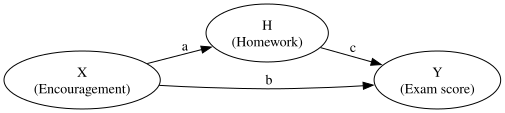

In [3]:
dag = Digraph()
dag.attr(rankdir="LR")
dag.node("X", "X\n(Encouragement)")
dag.node("H", "H\n(Homework)")
dag.node("Y", "Y\n(Exam score)")
dag.edge("X", "H", label=" a")
dag.edge("H", "Y", label=" c")
dag.edge("X", "Y", label=" b")
dag

**Caption:** DAG for the encouragement design. Encouragement ($X$) affects exam score ($Y$) directly (coefficient $b$) and indirectly through homework ($H$, coefficients $a$ and $c$).

## Simulate data and fit the structural model

We generate $N = 500$ observations from the structural equations, then fit a PyMC model to recover the coefficients.

In [4]:
N = 500

TRUE_A = 0.5
TRUE_B = 0.7
TRUE_C = 0.4

U_X = rng.normal(0, 1, N)
U_H = rng.normal(0, 1, N)
U_Y = rng.normal(0, 1, N)

X_data = U_X
H_data = TRUE_A * X_data + U_H
Y_data = TRUE_B * X_data + TRUE_C * H_data + U_Y

# Joe's observed values
joe_X = 0.5
joe_H = 1.0
joe_Y = 1.5

# Analytical reference values
ANALYTICAL_INTERVENTION = 2 * TRUE_C
ANALYTICAL_COUNTERFACTUAL = joe_Y + TRUE_C * (2 - joe_H)

print(f"Analytical E[Y | do(H=2)] = {ANALYTICAL_INTERVENTION:.2f}")
print(f"Analytical Y_{{H=2}} for Joe = {ANALYTICAL_COUNTERFACTUAL:.2f}")

Analytical E[Y | do(H=2)] = 0.80
Analytical Y_{H=2} for Joe = 1.90


The PyMC model mirrors the structural equations. Each equation becomes a likelihood statement, and we place weakly informative priors on the coefficients and noise standard deviations.

In [5]:
with pm.Model() as scm:
    a = pm.Normal("a", mu=0, sigma=2)
    b = pm.Normal("b", mu=0, sigma=2)
    c = pm.Normal("c", mu=0, sigma=2)

    sigma_X = pm.HalfNormal("sigma_X", sigma=2)
    sigma_H = pm.HalfNormal("sigma_H", sigma=2)
    sigma_Y = pm.HalfNormal("sigma_Y", sigma=2)

    X = pm.Normal("X", mu=0, sigma=sigma_X, observed=X_data)
    H = pm.Normal("H", mu=a * X, sigma=sigma_H, observed=H_data)
    Y = pm.Normal("Y", mu=b * X + c * H, sigma=sigma_Y, observed=Y_data)

    idata = pm.sample(draws=2000, random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, c, sigma_X, sigma_H, sigma_Y]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [6]:
summary = az.summary(
    idata,
    var_names=["a", "b", "c", "sigma_X", "sigma_H", "sigma_Y"],
    kind="stats",
)
summary["true_value"] = [TRUE_A, TRUE_B, TRUE_C, 1.0, 1.0, 1.0]
summary[["mean", "sd", "hdi_3%", "hdi_97%", "true_value"]]

,mean,sd,hdi_3%,hdi_97%,true_value
a,0.491,0.048,0.400,0.579,0.5
b,0.773,0.052,0.675,0.871,0.7
c,0.363,0.045,0.281,0.451,0.4
sigma_X,0.961,0.030,0.904,1.016,1.0
sigma_H,1.021,0.032,0.962,1.082,1.0
sigma_Y,1.023,0.032,0.960,1.082,1.0


The posterior means are close to the true values, and all true values fall within the 94% HDI. The model has recovered the structural relationships.

## The population intervention: $E[Y \mid \operatorname{do}(H\!=\!2)]$

The do-operator answers: "What happens on average if we set everyone's homework to 2?" Under $\operatorname{do}(H\!=\!2)$, the structural equation for $H$ is replaced with the constant $H = 2$, severing the causal link from $X$ to $H$. The equation for $Y$ becomes:

$$Y = bX + c \cdot 2 + U_Y$$

Taking expectations over the population ($E[X] = 0$, $E[U_Y] = 0$):

$$E[Y \mid \operatorname{do}(H\!=\!2)] = 2c$$

We compute this for each posterior draw to propagate coefficient uncertainty.

In [7]:
posterior = idata.posterior
c_draws = posterior["c"].values.flatten()
b_draws = posterior["b"].values.flatten()

intervention_ey = 2 * c_draws

print(f"Posterior mean of E[Y | do(H=2)]: {intervention_ey.mean():.3f}")
print(f"Analytical value: {ANALYTICAL_INTERVENTION:.3f}")

Posterior mean of E[Y | do(H=2)]: 0.727
Analytical value: 0.800


For Joe, the population intervention predicts a score of approximately $0.8$ — below his observed $1.5$. The do-operator averages over all possible individual characteristics. It knows nothing about Joe's above-average ability, his specific level of encouragement, or any other factor that made him who he is. It treats him as a generic member of the population.

To answer Joe's question, we need to preserve his individual characteristics.

## The exogenous terms are not noise

The key insight that separates counterfactual from interventional reasoning is a reinterpretation of the exogenous terms $U$.

In standard regression, residuals are exchangeable estimation error — interchangeable across individuals, carrying no individual meaning. In a structural causal model, $U_Y$ encodes everything about a specific person that causally affects $Y$ but is not measured: inherent ability, sleep quality, motivation, prior knowledge. Across the population, these factors look like zero-mean noise. For a specific individual, they are **fixed causal properties**.

:::{important} The dual nature of $U$
Across the population, $U_Y$ behaves like noise: zero mean, uncorrelated with measured variables. For a specific individual, $U_Y$ is a fixed property encoding all unmeasured causal factors that affect the outcome. This reinterpretation — from "discardable error" to "signal about the individual" — is what enables counterfactual reasoning.
:::

For Joe, his exogenous value is:

$$U_Y^{\text{Joe}} = Y - bX - cH = 1.5 - 0.7 \cdot 0.5 - 0.4 \cdot 1.0 = 0.75$$

Joe has above-average inherent ability. The counterfactual procedure preserves this; the population intervention discards it.

## Pearl's three-step counterfactual procedure

The population intervention asks what happens when we change the world for everyone. A counterfactual asks what would have happened to a specific individual in a world that *did not occur*, given what we observed in the world that *did*.

Pearl's three-step procedure turns a fitted structural causal model into a counterfactual engine.

### Step 1: Abduction — infer Joe's exogenous values

Given Joe's observed data $(X = 0.5, H = 1.0, Y = 1.5)$ and the structural equations, we solve for his individual exogenous values. For each posterior draw, the coefficients differ slightly, so Joe's inferred $U_Y$ varies across draws:

$$U_Y^{\text{Joe}} = Y_{\text{obs}} - b \cdot X_{\text{obs}} - c \cdot H_{\text{obs}}$$

In [8]:
u_y_joe = joe_Y - b_draws * joe_X - c_draws * joe_H

analytical_u_y = joe_Y - TRUE_B * joe_X - TRUE_C * joe_H
print(f"Posterior mean of U_Y (Joe): {u_y_joe.mean():.3f}")
print(f"Analytical U_Y (Joe): {analytical_u_y:.3f}")

Posterior mean of U_Y (Joe): 0.750
Analytical U_Y (Joe): 0.750


### Step 2: Action — set the intervention

Replace the structural equation for homework with the counterfactual value $H = 2$. All other equations and Joe's abducted exogenous values remain unchanged.

### Step 3: Prediction — compute the counterfactual outcome

Propagate through the modified model using Joe's individual $U_Y$:

$$Y_{H=2}^{\text{Joe}} = b \cdot X_{\text{obs}} + c \cdot 2 + U_Y^{\text{Joe}}$$

Substituting the abduction result reveals a clean simplification:

$$Y_{H=2}^{\text{Joe}} = Y_{\text{obs}} + c \cdot (2 - H_{\text{obs}})$$

In a linear SEM, the counterfactual reduces to the observed outcome plus the structural coefficient times the change in the intervened variable. The $b$ terms and the exogenous term cancel exactly.

In [9]:
y_cf_joe = joe_Y + c_draws * (2 - joe_H)

print(f"Posterior mean of Y_{{H=2}} (Joe): {y_cf_joe.mean():.3f}")
print(f"Analytical Y_{{H=2}} (Joe): {ANALYTICAL_COUNTERFACTUAL:.3f}")

Posterior mean of Y_{H=2} (Joe): 1.863
Analytical Y_{H=2} (Joe): 1.900


:::{tip} Linear SEM shortcut
In a linear structural equation model, the counterfactual change in $Y$ when intervening on a direct parent $H$ is $c \cdot (H' - H_{\text{obs}})$, where $c$ is the structural coefficient. This elegant cancellation does not hold in nonlinear models, where the full three-step procedure is necessary.
:::

## Intervention versus counterfactual

/var/folders/r0/nf1kgxsx6zx3rw16xc3wnnzr0000gn/T/ipykernel_12360/1678486857.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


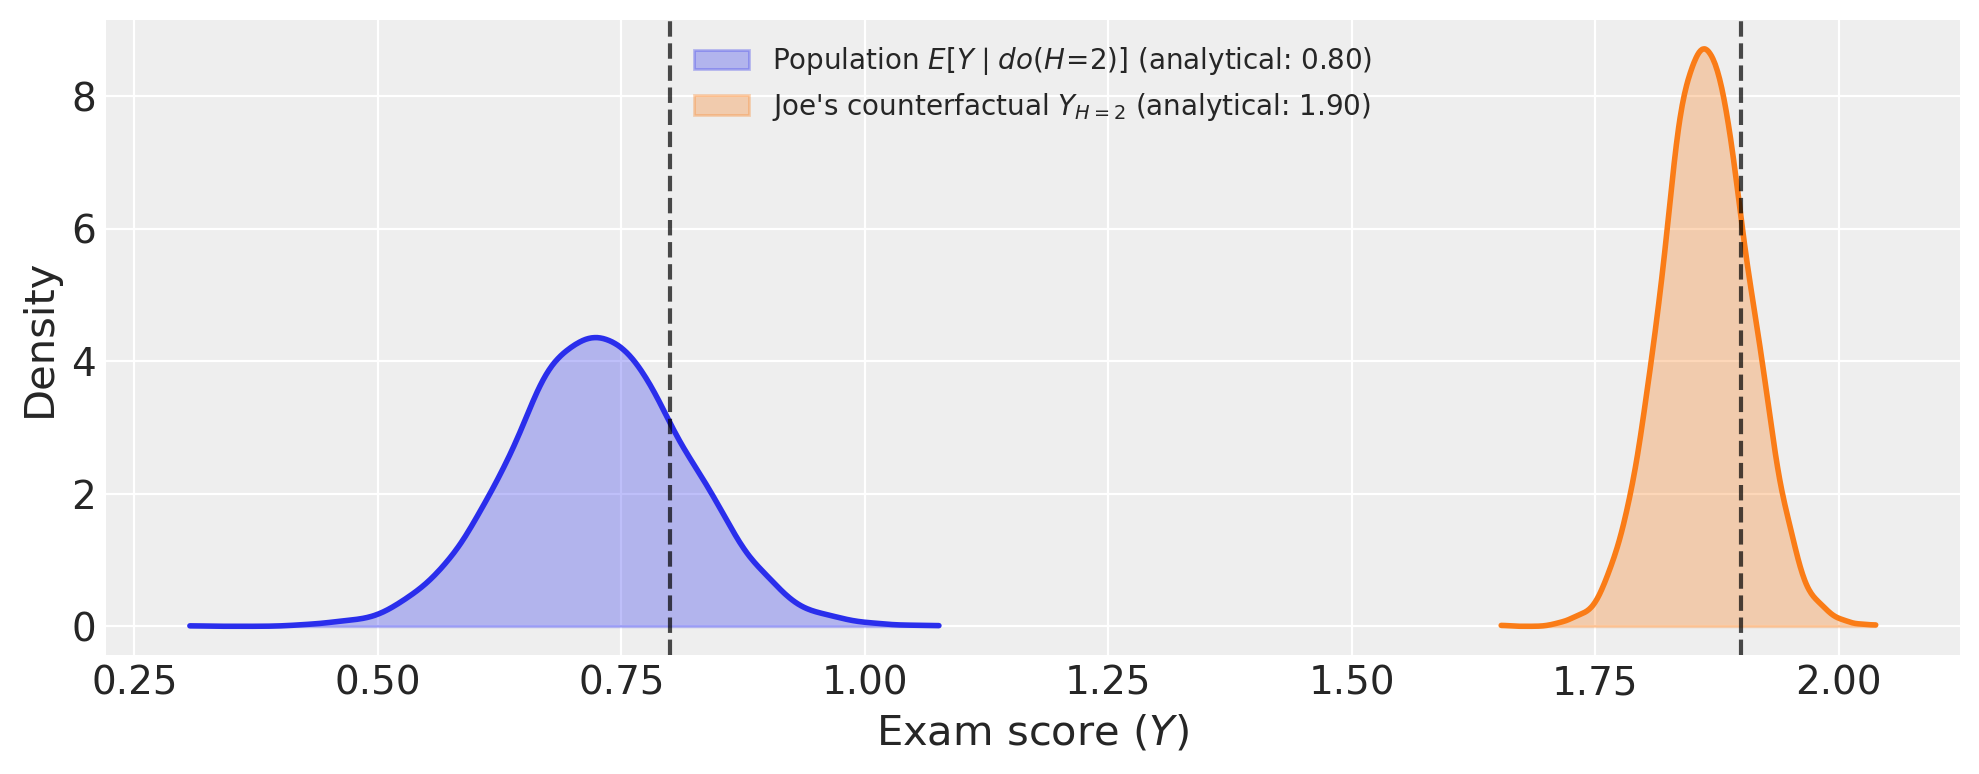

In [10]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

az.plot_kde(
    intervention_ey,
    ax=ax,
    plot_kwargs={"color": COLOR_POPULATION, "lw": 2},
    fill_kwargs={"color": COLOR_POPULATION, "alpha": 0.3},
    label=rf"Population $E[Y \mid do(H\!=\!2)]$ (analytical: {ANALYTICAL_INTERVENTION:.2f})",
)

az.plot_kde(
    y_cf_joe,
    ax=ax,
    plot_kwargs={"color": COLOR_JOE, "lw": 2},
    fill_kwargs={"color": COLOR_JOE, "alpha": 0.3},
    label=rf"Joe's counterfactual $Y_{{H=2}}$ (analytical: {ANALYTICAL_COUNTERFACTUAL:.2f})",
)

ax.axvline(ANALYTICAL_INTERVENTION, color="black", ls="--", lw=1.5, alpha=0.7)
ax.axvline(ANALYTICAL_COUNTERFACTUAL, color="black", ls="--", lw=1.5, alpha=0.7)

ax.set_xlabel("Exam score ($Y$)")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Caption:** Posterior distributions of the population-level intervention $E[Y \mid \operatorname{do}(H\!=\!2)]$ and Joe's unit-level counterfactual $Y_{H=2}$. Black dashed lines mark the analytical values. The gap reflects Joe's above-average individual characteristics ($U_Y \approx 0.75$), which the population intervention averages away.

## Joe's counterfactual posterior

/var/folders/r0/nf1kgxsx6zx3rw16xc3wnnzr0000gn/T/ipykernel_12360/3557695747.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


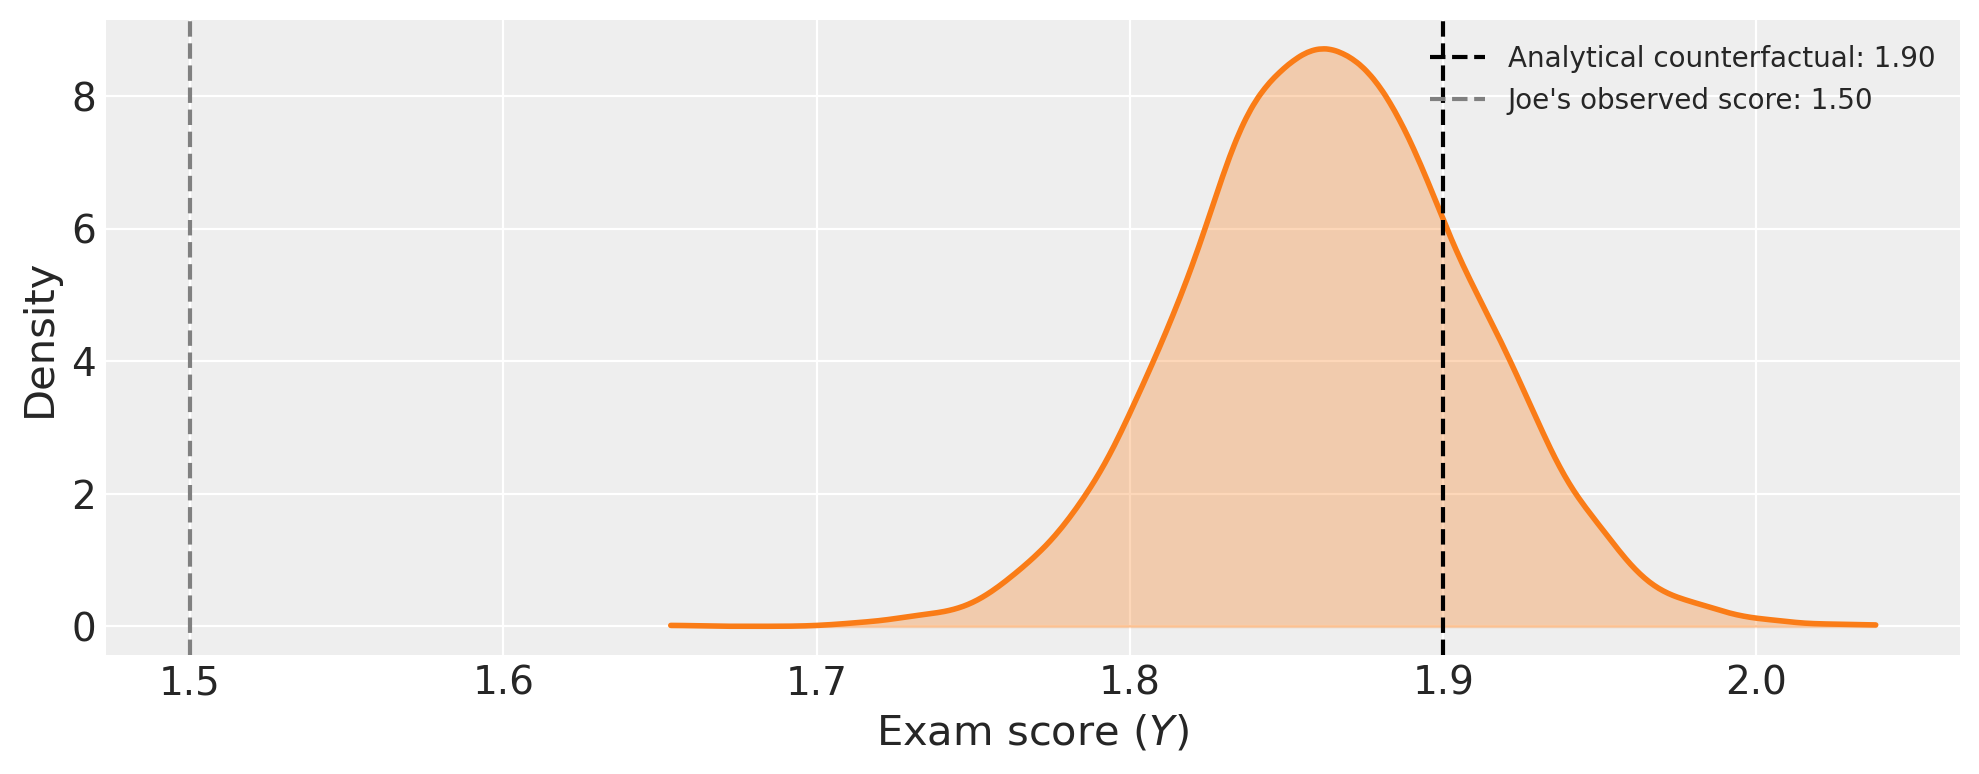

In [11]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

az.plot_kde(
    y_cf_joe,
    ax=ax,
    plot_kwargs={"color": COLOR_JOE, "lw": 2},
    fill_kwargs={"color": COLOR_JOE, "alpha": 0.3},
)

ax.axvline(
    ANALYTICAL_COUNTERFACTUAL,
    color="black",
    ls="--",
    lw=1.5,
    label=f"Analytical counterfactual: {ANALYTICAL_COUNTERFACTUAL:.2f}",
)
ax.axvline(
    joe_Y,
    color="gray",
    ls="--",
    lw=1.5,
    label=f"Joe's observed score: {joe_Y:.2f}",
)

ax.set_xlabel("Exam score ($Y$)")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Caption:** Posterior distribution of Joe's counterfactual exam score under $H = 2$, with the analytical counterfactual (1.90, black dashed) and Joe's observed score (1.50, gray dashed). The counterfactual is higher than the observed score because additional homework has a positive causal effect ($c > 0$), and Joe's above-average ability is preserved.

## Putting it together

| | Intervention: $E[Y \mid \operatorname{do}(H\!=\!2)]$ | Counterfactual: $Y_{H=2}$ for Joe |
|---|---|---|
| **Question** | What happens on average if we set everyone's homework to 2? | What would Joe's score have been if he had done $H\!=\!2$? |
| **Uses individual data?** | No | Yes — conditions on Joe's observed $(X, H, Y)$ |
| **Exogenous values** | Population mean ($U \approx 0$) | Joe's inferred values ($U_Y \approx 0.75$) |
| **Causal ladder** | Rung 2 (intervention) | Rung 3 (counterfactual) |
| **Result** | $\approx 0.80$ | $\approx 1.90$ |

:::{warning}
`pm.do` alone does not produce unit-level counterfactuals. It computes interventional distributions (rung 2), which average over all individual characteristics. For unit-level counterfactuals (rung 3), the additional abduction step — inferring the individual's exogenous values from observed data — is essential.
:::

## Summary

- **The exogenous terms ($U$) are not noise** — they encode everything about a specific individual that causally affects the outcome but is not measured. Across the population they look like zero-mean error; for a specific person they are fixed causal properties.
- **Counterfactuals** answer questions about specific individuals under hypothetical conditions by conditioning on observed evidence before intervening.
- **Pearl's three-step procedure** — abduction, action, prediction — turns a fitted structural causal model into a counterfactual engine.
- **`do()` answers a different question**: the population-level average effect of an intervention. For Joe, $\operatorname{do}(H\!=\!2)$ predicts $\approx 0.8$; the counterfactual predicts $\approx 1.9$.
- **In a Bayesian framework**, the three-step procedure yields a full posterior over the counterfactual outcome, naturally propagating coefficient uncertainty through every step.
- **In linear SEMs**, the counterfactual simplifies: $Y_{H=h'} = Y_{\text{obs}} + c \cdot (h' - H_{\text{obs}})$. In nonlinear models, the full three-step procedure is required.

## Reflection

When have you wanted to answer a question about a *specific case* rather than a population average?

- **Medicine**: A patient took drug A and recovered slowly. Would drug B have worked better *for this patient*, given their specific medical history?
- **Marketing**: A customer saw campaign A and didn't convert. Would they have converted under campaign B, given their browsing behavior and demographics?
- **Education**: A student attended tutoring but still struggled. Would a different teaching method have helped *this student*, given their prior performance and learning style?

In each case, the population-level answer ($\operatorname{do}$) and the individual answer (counterfactual) can diverge substantially — especially for individuals far from the population mean.

## Authors

- Authored by [Benjamin T. Vincent](https://github.com/drbenvincent) in March 2026

## References

:::{bibliography}
:filter: docname in docnames
:::

In [12]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Thu, 05 Mar 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.11.0

pytensor: 2.38.1
xarray  : 2026.2.0

arviz     : 0.23.4
graphviz  : 0.21
matplotlib: 3.10.8
numpy     : 2.4.2
pymc      : 5.28.1

Watermark: 2.6.0



:::{include} ../page_footer.md
:::